In [1]:
!pip install pandas numpy scikit-learn gensim pyLDAvis matplotlib seaborn plotly


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /Users/sonia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/sonia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/sonia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [11]:
df = pd.read_csv('dei_tweets_merged.csv')
tweets = df['text'].dropna().astype(str).tolist()

with open('stopwords.txt', 'r') as f:
    custom_stopwords = set([line.strip().lower() for line in f])

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_text(text):
    """Clean and preprocess tweet text"""
    # Remove URLs, mentions, and hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()

    # Tokenize and lemmatize
    tokens = text.split()
    lemmatized_tokens = []

    for token in tokens:
        if len(token) > 2 and token not in custom_stopwords:
            pos = get_wordnet_pos(token)
            lemma = lemmatizer.lemmatize(token, pos=pos)
            lemmatized_tokens.append(lemma)

    return ' '.join(lemmatized_tokens)

# Apply preprocessing
processed_tweets = [preprocess_text(tweet) for tweet in tweets]

In [12]:
# Create document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm = vectorizer.fit_transform(processed_tweets)
feature_names = vectorizer.get_feature_names_out()

print(f"Number of tweets: {len(processed_tweets)}")
print(f"Vocabulary size: {len(feature_names)}")

Number of tweets: 2026
Vocabulary size: 1000


In [13]:
n_topics = 10
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    learning_method='online',
    learning_offset=50.
)

lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",50.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [6]:
# Analyze topic distributions
def display_topics(model, feature_names, n_top_words=10):
    """Display top words for each topic"""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics[f'Topic_{topic_idx}'] = top_features
        print(f"Topic {topic_idx}:")
        print(" ".join(top_features))
        print()
    return topics

# Display topics
topics = display_topics(lda, feature_names, n_top_words=10)

# Get document-topic distributions
doc_topic_dist = lda.transform(dtm)
dominant_topics = doc_topic_dist.argmax(axis=1)

# Calculate topic dominance
topic_dominance = np.bincount(dominant_topics, minlength=n_topics)
topic_percentages = (topic_dominance / len(dominant_topics)) * 100

Topic 0:
biodiversity bias growth critical solution climate twitter deep strong forum

Topic 1:
dont love top world discrimination esg bias act hatred stand

Topic 2:
community employee woman celebrate lgbtq support work day team proud

Topic 3:
work great business create support future inclusive change employee important

Topic 4:
represent time woke company today school happen summit day love

Topic 5:
close ceo gap award great change company social country healthequity

Topic 6:
workplace community introduce show tool put company product platform full

Topic 7:
place year equality employee work corporate tmobile human proud promote

Topic 8:
equality equal gender pay woman work salesforce equalityforall men opportunity

Topic 9:
diversity equity inclusion people proud honor company commitment equality world



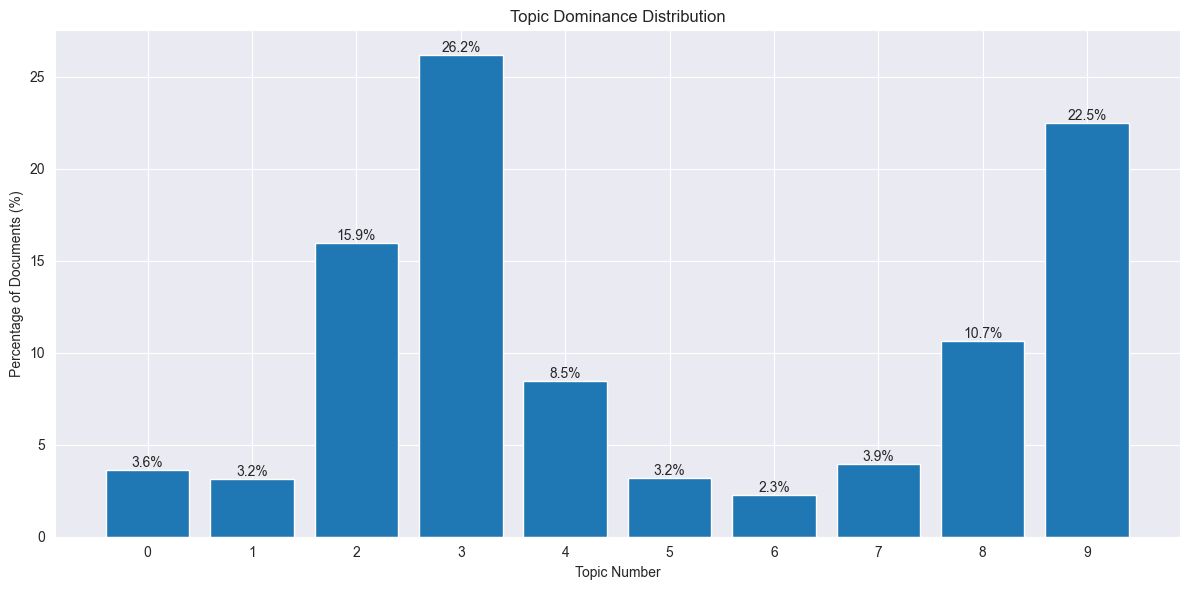

Top 5 Most Dominant Topics:
Topic 3: 26.2% of tweets
Top words: work great business create support

Topic 9: 22.5% of tweets
Top words: diversity equity inclusion people proud

Topic 2: 15.9% of tweets
Top words: community employee woman celebrate lgbtq

Topic 8: 10.7% of tweets
Top words: equality equal gender pay woman

Topic 4: 8.5% of tweets
Top words: represent time woke company today



In [7]:
# Visualize dominant topics
# Plot topic distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(range(n_topics), topic_percentages)
plt.xlabel('Topic Number')
plt.ylabel('Percentage of Documents (%)')
plt.title('Topic Dominance Distribution')
plt.xticks(range(n_topics))

# Add percentage labels
for bar, percentage in zip(bars, topic_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Display top topics
print("Top 5 Most Dominant Topics:")
dominant_indices = topic_percentages.argsort()[-5:][::-1]
for idx in dominant_indices:
    print(f"Topic {idx}: {topic_percentages[idx]:.1f}% of tweets")
    print(f"Top words: {' '.join(topics[f'Topic_{idx}'][:5])}")
    print()

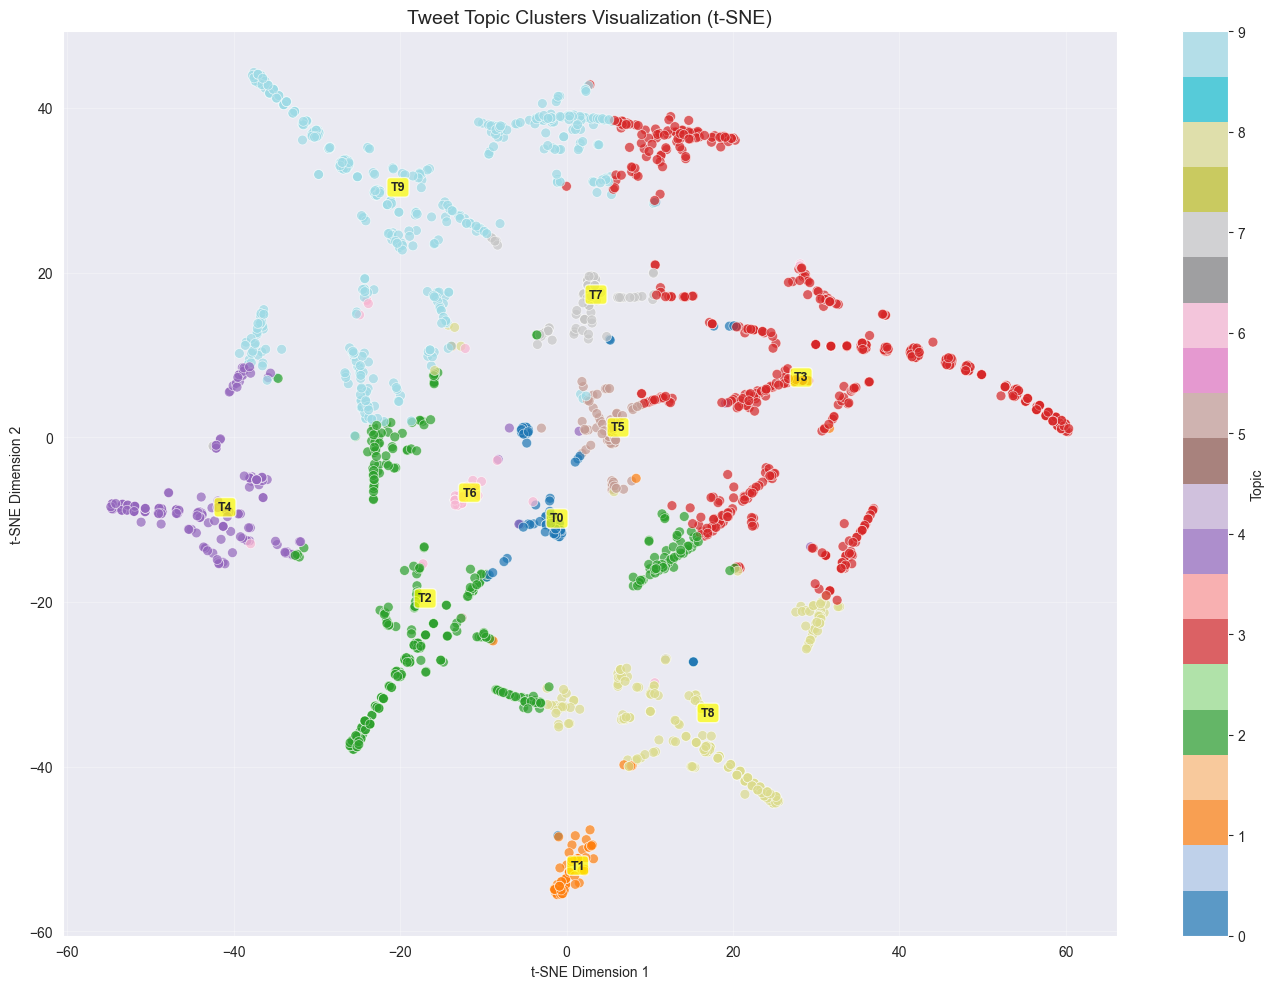

In [8]:
# Visualize clusters with t-SNE
# Reduce dimensionality for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
doc_embeddings_2d = tsne.fit_transform(doc_topic_dist)

# Create visualization dataframe
vis_df = pd.DataFrame({
    'x': doc_embeddings_2d[:, 0],
    'y': doc_embeddings_2d[:, 1],
    'topic': dominant_topics,
    'dominant_topic_prob': doc_topic_dist.max(axis=1)
})

# Plot with matplotlib
plt.figure(figsize=(14, 10))
scatter = plt.scatter(vis_df['x'], vis_df['y'],
                     c=vis_df['topic'],
                     cmap='tab20',
                     alpha=0.7,
                     s=50,
                     edgecolors='w',
                     linewidth=0.5)

plt.colorbar(scatter, label='Topic')
plt.title('Tweet Topic Clusters Visualization (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)

# Add topic labels at cluster centers
for topic in range(n_topics):
    topic_points = vis_df[vis_df['topic'] == topic]
    if len(topic_points) > 0:
        center_x = topic_points['x'].median()
        center_y = topic_points['y'].median()
        plt.annotate(f'T{topic}',
                    (center_x, center_y),
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3",
                             facecolor='yellow',
                             alpha=0.7))

plt.tight_layout()
plt.show()

In [9]:
# Generate topic summary report
print("=" * 80)
print("TOPIC ANALYSIS SUMMARY REPORT")
print("=" * 80)

# 1. Topic dominance summary
print("\n1. TOPIC DOMINANCE:")
for idx in np.argsort(-topic_percentages):
    print(f"Topic {idx:2d}: {topic_percentages[idx]:5.1f}% - {' '.join(topics[f'Topic_{idx}'][:5])}")

# 2. Topic distinctness analysis
print("\n\n2. TOPIC DISTINCTNESS ANALYSIS:")
avg_similarity = np.mean(topic_similarity - np.eye(n_topics))  # Exclude self-similarity
print(f"Average inter-topic similarity: {avg_similarity:.3f}")
print(f"Topics with high similarity (>0.3):")
for i in range(n_topics):
    for j in range(i+1, n_topics):
        if topic_similarity[i, j] > 0.3:
            print(f"  Topic {i} & Topic {j}: {topic_similarity[i, j]:.3f}")

# 3. Common terms analysis
print(f"\n\n3. COMMON TERMS ACROSS TOPICS:")
print(f"Found {len(common_terms)} terms appearing in multiple topics")
print(f"Most common overlapping terms: {', '.join(common_terms[:15])}")

# 4. Cluster quality
print(f"\n\n4. CLUSTER QUALITY:")
print(f"Average confidence per tweet: {vis_df['dominant_topic_prob'].mean():.3f}")
print(f"Tweets with low confidence (<0.5): {(vis_df['dominant_topic_prob'] < 0.5).sum()} ({(vis_df['dominant_topic_prob'] < 0.5).mean()*100:.1f}%)")

print("\n" + "=" * 80)

TOPIC ANALYSIS SUMMARY REPORT

1. TOPIC DOMINANCE:
Topic  3:  26.2% - work great business create support
Topic  9:  22.5% - diversity equity inclusion people proud
Topic  2:  15.9% - community employee woman celebrate lgbtq
Topic  8:  10.7% - equality equal gender pay woman
Topic  4:   8.5% - represent time woke company today
Topic  7:   3.9% - place year equality employee work
Topic  0:   3.6% - biodiversity bias growth critical solution
Topic  5:   3.2% - close ceo gap award great
Topic  1:   3.2% - dont love top world discrimination
Topic  6:   2.3% - workplace community introduce show tool


2. TOPIC DISTINCTNESS ANALYSIS:


NameError: name 'topic_similarity' is not defined

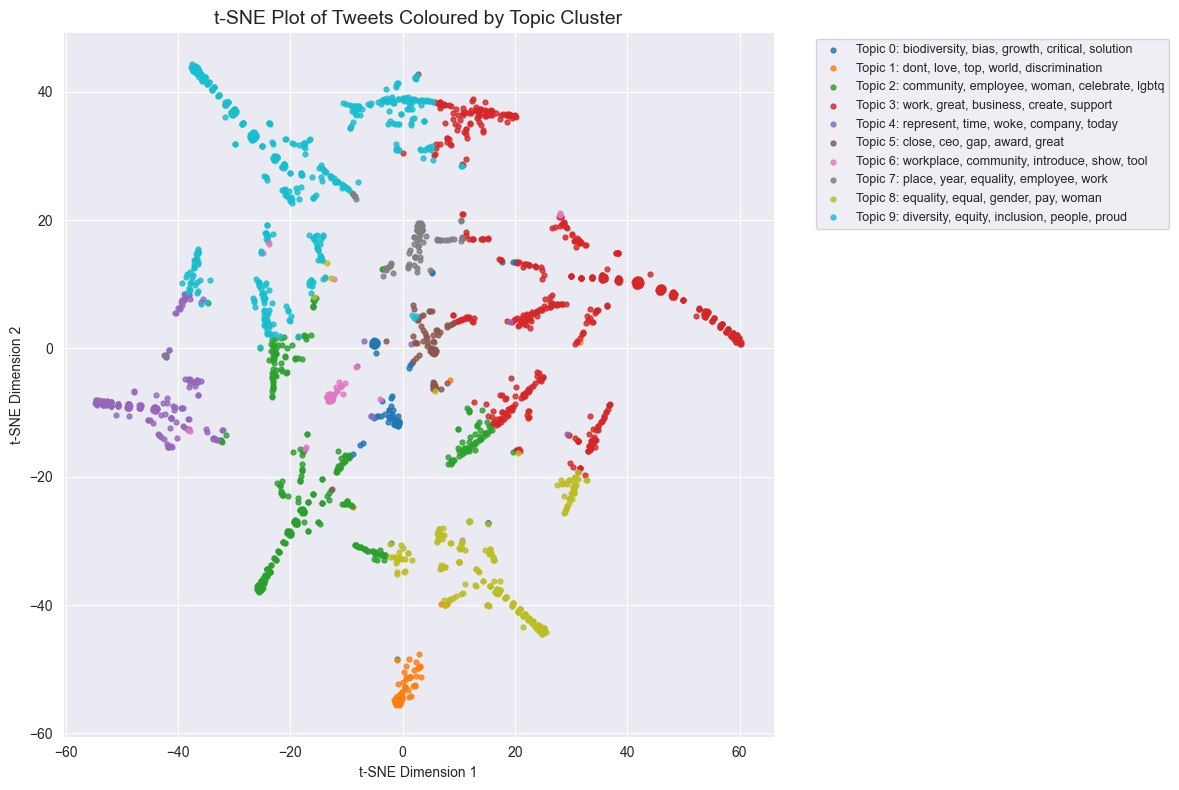

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- 1. Get topic distributions for each tweet ---
# dtm is your document-term matrix
topic_distributions = lda.transform(dtm)   # shape: (n_docs, n_topics)

# --- 2. Run t-SNE on topic vectors ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_coords = tsne.fit_transform(topic_distributions)

x = tsne_coords[:, 0]
y = tsne_coords[:, 1]

# --- 3. Assign each tweet to its highest-probability topic ---
clusters = np.argmax(topic_distributions, axis=1)

# --- 4. Extract top 5 words per cluster from LDA ---
top_words = {}
for topic_idx, topic in enumerate(lda.components_):
    top_word_indices = np.argsort(topic)[::-1][:5]
    top_words[topic_idx] = [feature_names[i] for i in top_word_indices]

# --- 5. Plot with distinct colours ---
plt.figure(figsize=(12, 8))

# Distinct colour map
cmap = plt.cm.get_cmap('tab10', lda.n_components)

for topic_idx in range(lda.n_components):
    mask = clusters == topic_idx
    plt.scatter(
        x[mask],
        y[mask],
        s=12,
        alpha=0.8,
        color=cmap(topic_idx),
        label=f"Topic {topic_idx}: " + ", ".join(top_words[topic_idx])
    )

plt.title("t-SNE Plot of Tweets Coloured by Topic Cluster", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
